In [445]:
import numpy as np
import matplotlib.pyplot as plt

In [446]:
##Helpers
def CalculateCentralDifference(F, dx, dy):
    dFdx = (F[2:, 1:-1] - F[:-2, 1:-1])/(2*dx)
    dFdy = (F[1:-1, 2:] - F[1:-1, :-2])/(2*dy)
    return dFdx, dFdy

def CalculateCentralDifference2nd(F, dx, dy):
    ddFdx = (F[2:, 1:-1] - 2 * F[1:-1, 1:-1] + F[:-2, 1:-1])/(2*dx)
    ddFdy = (F[1:-1, 2:] - 2 * F[1:-1, 1:-1] + F[1:-1, :-2])/(2*dy)
    return ddFdx, ddFdy

def GetAdvectionDiffusionMatrix(u, v, dx, dy, alpha):  
    #U
    dUdx, dUdy = CalculateCentralDifference(u, dx, dy)
    ddUdx, ddUdy = CalculateCentralDifference2nd(u, dx, dy)

    advectionU = u[1: - 1] * dUdx + v[1: -1] * dUdy
    diffusionU = alpha*(ddUdx + ddUdy)
 
    #V
    dVdx, dVdy = CalculateCentralDifference(v, dx, dy)
    ddVdx, ddVdy = CalculateCentralDifference2nd(v, dx, dy)

    advectionV = u[1: - 1] * dVdx + v[1: -1] * dVdy
    diffusionV = alpha*(ddVdx + ddVdy)

    Hx = diffusionU - advectionU
    Hy = diffusionV - advectionV
    return Hx, Hy

def EnforceBoundaryConditions(u, v):
    u[:, 0] = 0
    u[:, -1] = 0
    u[-1, :] = 0.1
    u[0, :] = 0

    v[:, 0] = 0
    v[:, -1] = 0
    v[-1, :] = 0
    v[0, :] = 0
    return u, v

def EnforcePressureBoundary(p, dx, dy):
    #Bottom
    p[-1, :] = 0 
    #Left
    p[:, 0] = p[:, 1]
    #Right
    p[:, -1] = p[:, -2]
    #Top
    p[0, :] = p[1, :]
    return p



In [447]:
def Plot_Solution_Steady(T, u, v, p, Nx, Ny, Lx, Ly): 
    X, Y = GetMeshGrid(Nx, Ny, Lx, Ly)
    plt.figure(figsize=[11 ,11])
    cp = plt.contourf(X, Y, T)
    
    plt.quiver(X, Y, u, v)
    plt.colorbar(cp)
    plt.show()
    return

def Plot_Solution_Transient(u, v, p, Nx, Ny, Lx, Ly): 

    X, Y = GetMeshGrid(Nx, Ny, Lx, Ly)
    plt.figure(figsize=[11 ,11])
    cp = plt.contourf(X, Y, p)
    plt.quiver(X, Y, u, v)
    plt.colorbar(cp)

    plt.show()
    return

def Plot_Solution_Residual(continuity, numTimesteps):
    t = np.linspace(0, numTimesteps, numTimesteps)
    plt.plot(t, continuity)
    plt.show()


In [460]:
def Simple_Explicit_Navier_Solver(Nx, Ny, dx, dy, dt, L, numTimesteps):
    u = np.zeros((Ny, Nx))
    v = np.zeros((Ny, Nx))
    p = np.zeros((Ny, Nx))

    residual = np.zeros(numTimesteps)
    
    u, v = EnforceBoundaryConditions(u, v)

    for n in range (numTimesteps):
        if (n % 100 == 0):
            Plot_Solution_Transient(u, v, p, Nx, Ny, 1, 1)
            
        residual[n] = CalculateContinuityResidual(u, v, dx, dy)
        print(residual[n])
        for i in range(10):
            p = CalculatePressureOld(u, v, p, dx, dy, dt)
            p = EnforcePressureBoundary(p, dx, dy)

        dPdx, dPdy = CalculateCentralDifference(p, dx, dy)
        u, v, Hx, Hy = SolveAdvectionDiffusionFTCS(u, v, -dPdx, -dPdy, dx, dy, dt, L)
        u, v = EnforceBoundaryConditions(u, v)

    return u, v, p, residual

def SolveAdvectionDiffusionFTCS(u, v, sx, sy, dx, dy, dt, L):
    #U
    dUdx, dUdy = CalculateCentralDifference(u, dx, dy)
    ddUdx, ddUdy = CalculateCentralDifference2nd(u, dx, dy)

    advectionU = u[1:-1, 1:-1] * dUdx + v[1: -1, 1:-1] * dUdy
    diffusionU = L*(ddUdx + ddUdy)
    deltaU =  diffusionU - advectionU + sx

    u[1:-1, 1:-1] = u[1:-1, 1:-1] + dt * deltaU
 
    #V
    dVdx, dVdy = CalculateCentralDifference(v, dx, dy)
    ddVdx, ddVdy = CalculateCentralDifference2nd(v, dx, dy)

    advectionV = u[1: - 1, 1:-1] * dVdx + v[1: -1, 1:-1] * dVdy
    diffusionV = L*(ddVdx + ddVdy)
    deltaV =  diffusionV - advectionV + sy

    v[1:-1, 1:-1] = v[1:-1, 1:-1] + dt * deltaV

    Hx = diffusionU - advectionU
    Hy = diffusionV - advectionV

    return u, v, Hx, Hy

def CalculateContinuityResidual(u, v, dx, dy):
    dudx, dudy = CalculateCentralDifference(u, dx, dy)
    dvdx, dvdy = CalculateCentralDifference(v, dx, dy)
    return np.mean(dudx + dvdx)


def CalculatePressureOld(u, v, p, dx, dy, dt):
    dudx, dudy = CalculateCentralDifference(u, dx, dy)
    dvdx, dvdy = CalculateCentralDifference(v, dx, dy)

    residual = (1/dt) * (dudx + dudy)
    LHS = (np.square(dudx) + 2 * (dudy) * (dvdx) + np.square(dvdy))
    pressureTerms = p[2:, 1:-1] + p[:-2, 1:-1] + p[1:-1, 2:] + p[1:-1, :-2]

    p[1:-1, 1:-1] = (1/4) * ((dx**2 * LHS) - pressureTerms)
    return p


def CalculatePressure(u, v, p, dx, dy, dt):
    
    pTerm =  1/4*(p[2:, 1:-1] + p[:-2, 1:-1] + p[1:-1, 2:] + p[1:-1, :-2])
    term2 = 2/dt * (u[2:, 1:-1] - u[:-2, 1:-1] + v[1:-1, 2:] - v[1:-1, :-2])
    term3 = 2/dx * (u[1:-1, 2:] - u[1:-1, :-2]) * (v[2:, 1:-1] - v[:-2, 1:-1])
    term4 = np.square(u[2: , 1:-1] - u[:-2, 1:-1])/dx
    term5 = np.square(v[1:-1, 2:] - v[1:-1, :-2])/dx

    p[1:-1, 1:-1] = pTerm - (dx/16) * (term2 - term3 - term4 - term5)
    return p

def ExplicitCorrectMomentum(u, v ,p , dx, dy, dt, L, Hx, Hy):
    dPdx, dPdy = CalculateCentralDifference(p, dx, dy)

    u[1:-1] = u[1:-1] - dt * dPdx
    v[1:-1] = v[1:-1] - dt * dPdy

def ConstructMatrix(Nx, Ny, dx, dy):
    B = 1/dx**2
    y = -1/(2*dx)

    for j in range(Ny):
        for j in range(Nx):
            ##Need to construct matrix for central differences

            pass
    return

def GetMeshGrid(Nx, Ny, Lx, Ly):
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)

    X, Y = np.meshgrid(x, y)
    return X, Y


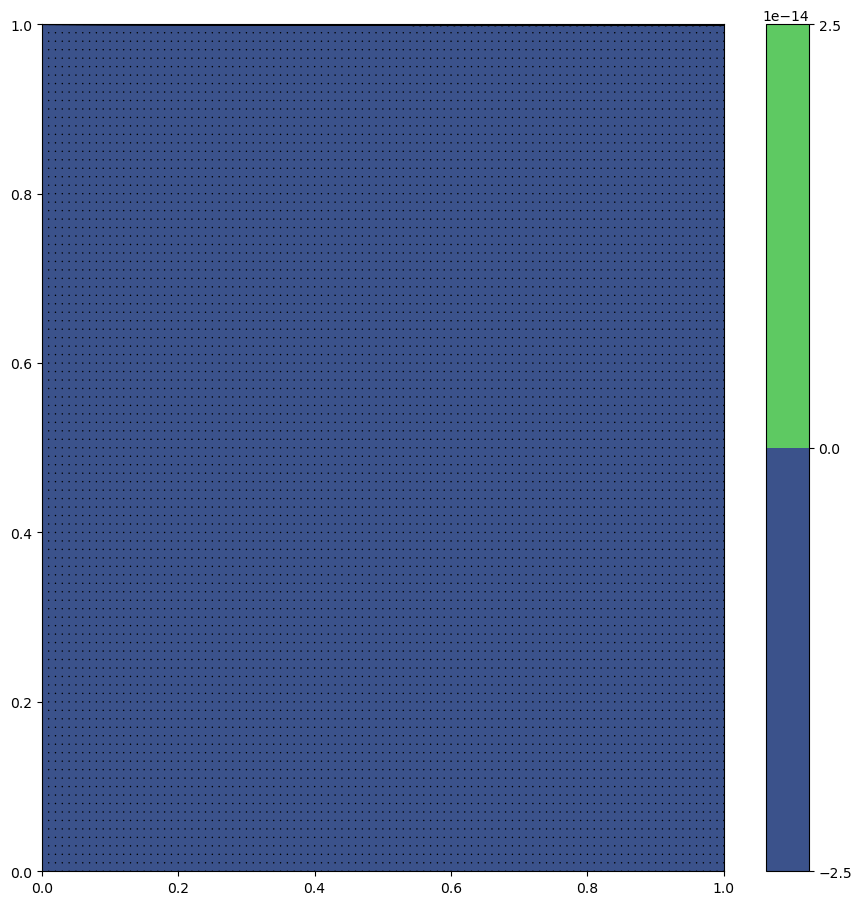

0.050505050505050504
0.05012927404557816
0.049812860279292874
0.049501827127470706
0.049180895678598784
0.04884326991771491
0.04848498923247183
0.048103332027859484
0.04769628033128769
0.047262371879095495
0.04680075652636647
0.04631141607661048
0.04579555493326164
0.04525615933174317
0.0446985895337236
0.04413055895520925
0.04355918188181375
0.0429775639026764
0.04231756446567172
0.041299494876333415
0.03902754960288571
0.03457774947672172
0.12073822204281165
45.334611003390904
13821862756.96836
7.202346734953138e+37
-7.59102240537087e+117
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


/tmp/ipykernel_1743/1018009267.py:41: RuntimeWarning: overflow encountered in multiply
  advectionV = u[1: - 1, 1:-1] * dVdx + v[1: -1, 1:-1] * dVdy
/tmp/ipykernel_1743/646220639.py:3: RuntimeWarning: invalid value encountered in subtract
  dFdx = (F[2:, 1:-1] - F[:-2, 1:-1])/(2*dx)
/tmp/ipykernel_1743/646220639.py:4: RuntimeWarning: invalid value encountered in subtract
  dFdy = (F[1:-1, 2:] - F[1:-1, :-2])/(2*dy)
/tmp/ipykernel_1743/1018009267.py:63: RuntimeWarning: overflow encountered in square
  LHS = residual - (np.square(dudx) + 2 * (dudy) * (dvdx) + np.square(dvdy))
/tmp/ipykernel_1743/1018009267.py:63: RuntimeWarning: overflow encountered in multiply
  LHS = residual - (np.square(dudx) + 2 * (dudy) * (dvdx) + np.square(dvdy))
/tmp/ipykernel_1743/1018009267.py:63: RuntimeWarning: invalid value encountered in add
  LHS = residual - (np.square(dudx) + 2 * (dudy) * (dvdx) + np.square(dvdy))
/tmp/ipykernel_1743/1018009267.py:66: RuntimeWarning: invalid value encountered in subtract

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


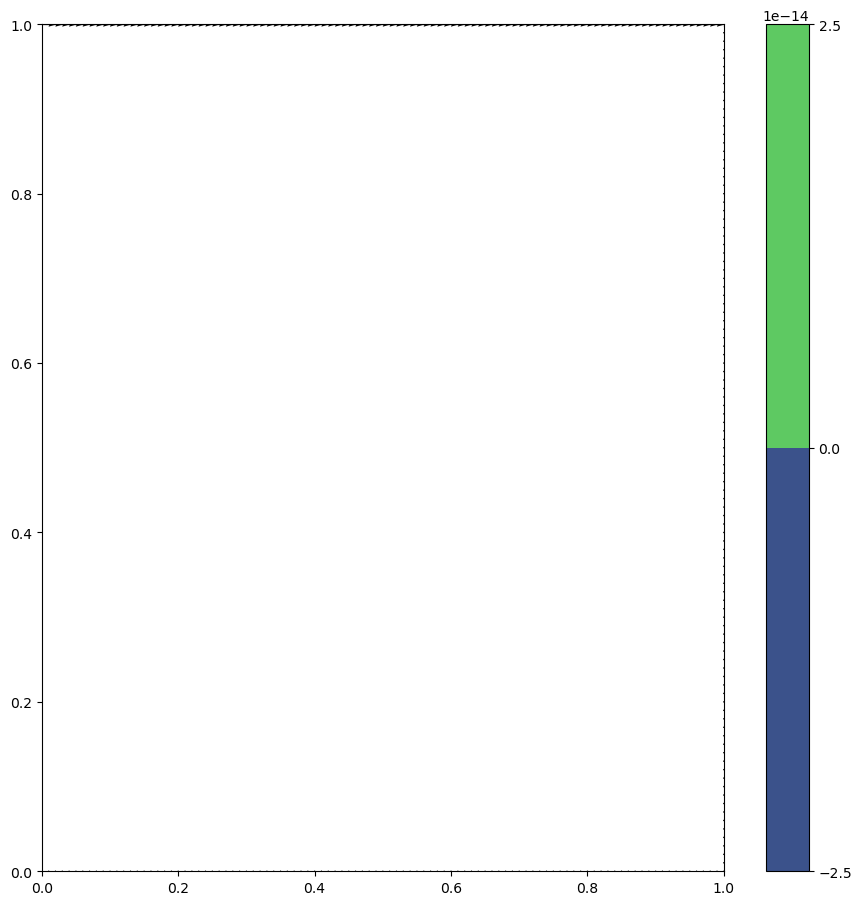

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


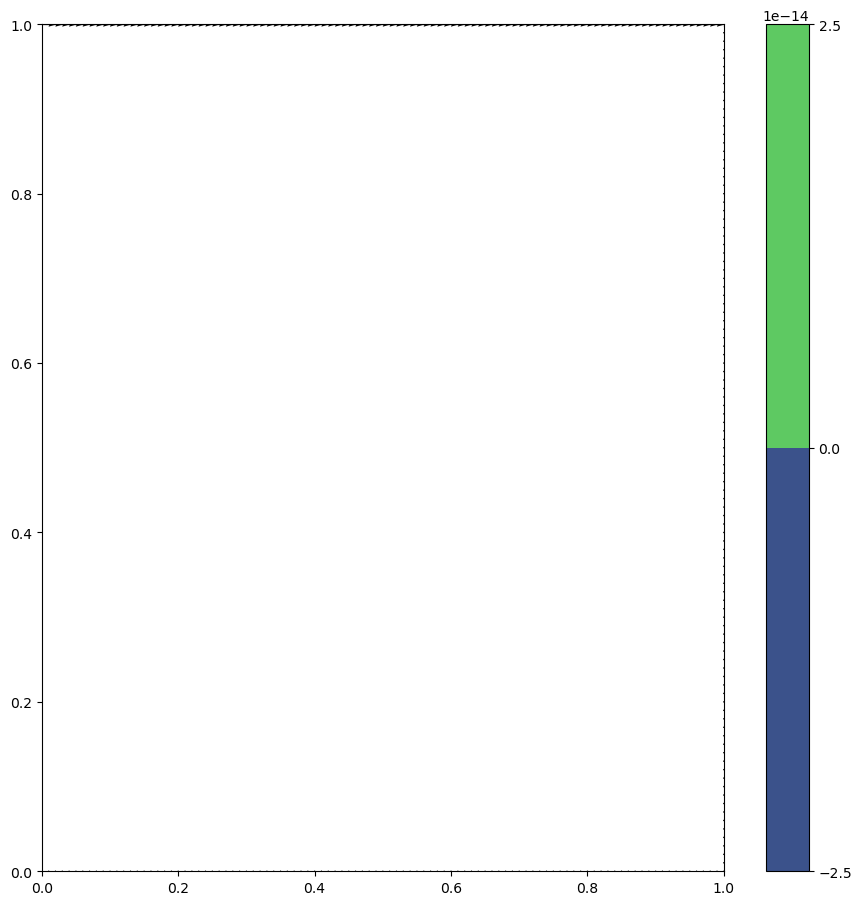

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


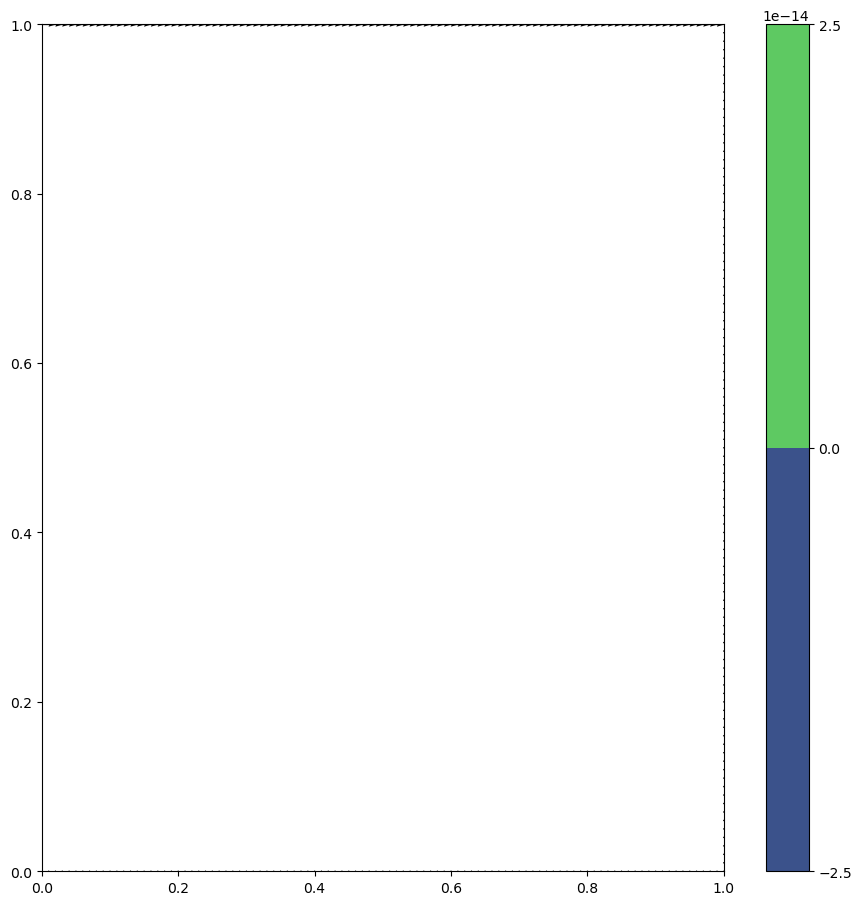

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [461]:
#  Input Data #
Lx = 1
Ly = 1
dx = 0.01
dy = 0.01
dt = 0.005

pho = 1000
visc = 0.01
tmax = 2

numTimesteps = int(tmax/dt)

Nx = int(Lx/dx) + 1
Ny = int(Ly/dy) + 1

u, v, p, continuity= Simple_Explicit_Navier_Solver(Nx, Ny, dx, dy, dt, visc, numTimesteps)


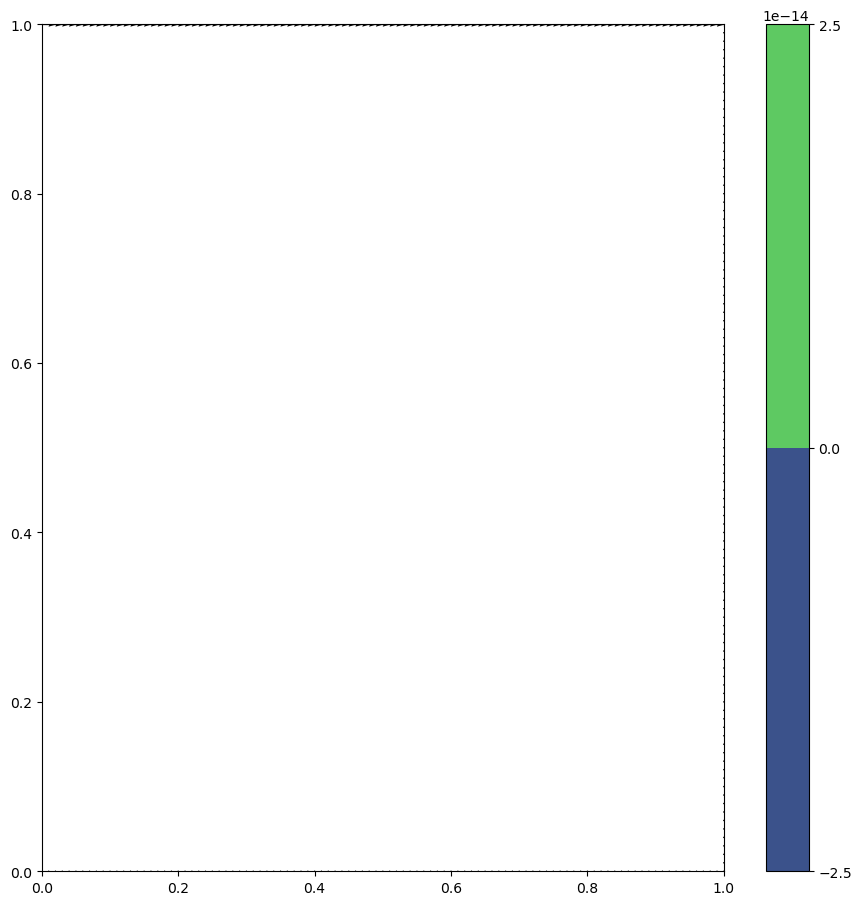

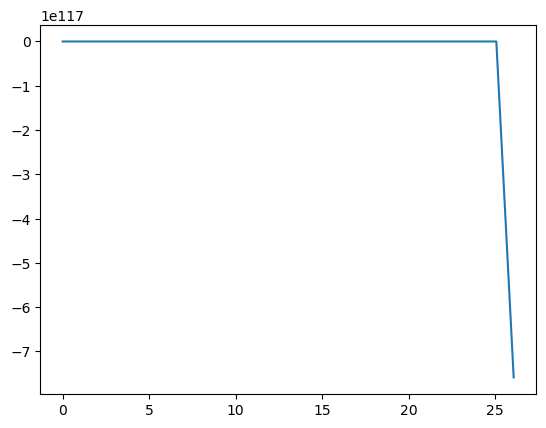

0.050505050505050504


In [462]:
Plot_Solution_Transient(u, v, pho * p, Nx, Ny, Lx, Ly)
Plot_Solution_Residual(continuity, numTimesteps)
print(continuity[0])

In [463]:
X, Y = GetMeshGrid(Nx, Ny, Lx, Ly)

f = 10
u = np.sin(f * Y)
v = X

p = np.zeros((Ny, Nx))
Plot_Solution_Steady(T, u, v, p, Nx, Ny, Lx, Ly)

NameError: name 'T' is not defined

0.0


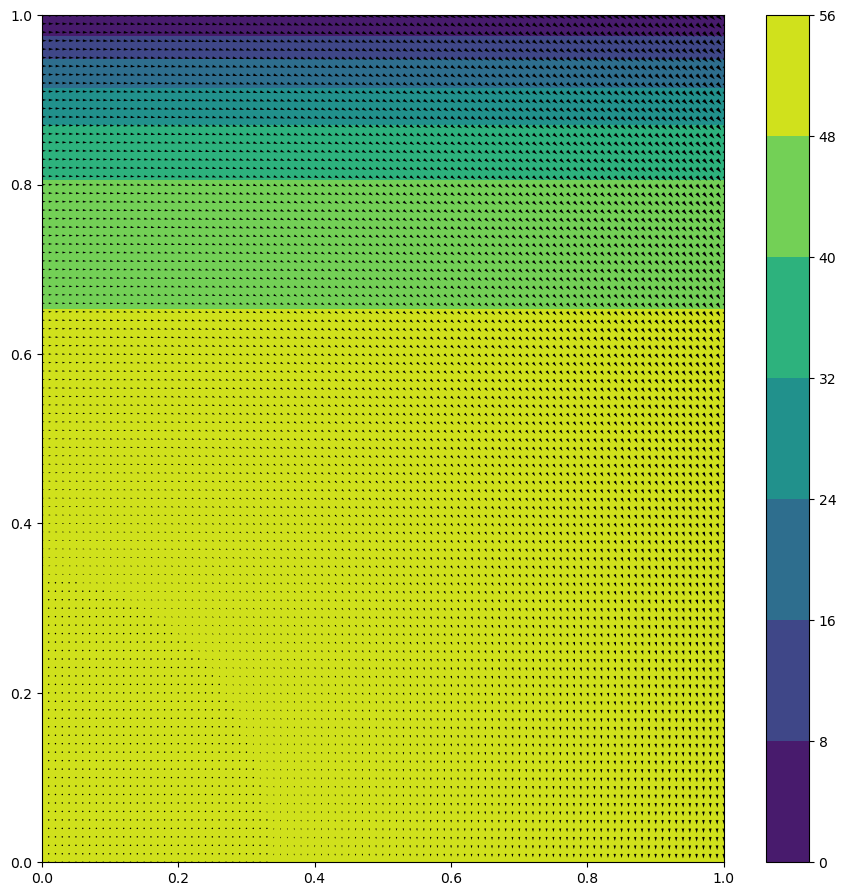

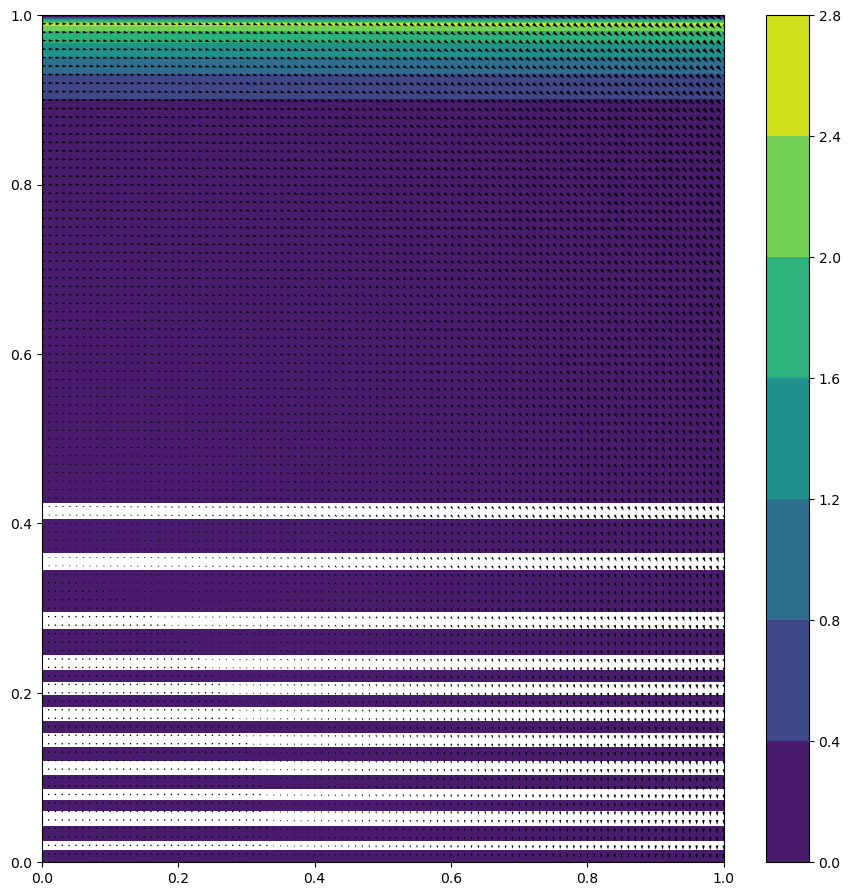

In [468]:
X, Y = GetMeshGrid(Nx, Ny, Lx, Ly)

f = 5
# u = np.sin(Y)
# v = np.cos(X)
u = Y
v = -X

p = np.zeros((Nx, Ny))

print(np.sum((u[2:, 1:-1] - u[:-2, 1:-1])/(2*dx) + (v[1:-1, 2:] - v[1:-1, :-2])/(2*dy)))

for i in range (1000):
    CalculatePressure(u, v, p, dx, dy, dt)
    EnforcePressureBoundary(p, dx, dy)

Plot_Solution_Transient(u, v, pho * p, Nx, Ny, Lx, Ly)

p = np.zeros((Nx, Ny))

for i in range (100):
    CalculatePressureOld(u, v, p, dx, dy, dt)
    EnforcePressureBoundary(p, dx, dy)

Plot_Solution_Transient(u, v, pho * p, Nx, Ny, Lx, Ly)
